In [1]:
import sys
sys.path.append("../")

# local imports
from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *
from plotting_functions import *

# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq


In [2]:
IB = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0., 'f': 0., 'tau': 0.}
    
IB_aut = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0.2, 'f': 150., 'tau': 0.}


neuron = AQUA(IB)

threshold, x_ini = neuron.get_threshold()

100%|██████████| 39999/39999 [00:05<00:00, 7844.55it/s]


100%|██████████| 499999/499999 [00:57<00:00, 8642.52it/s]


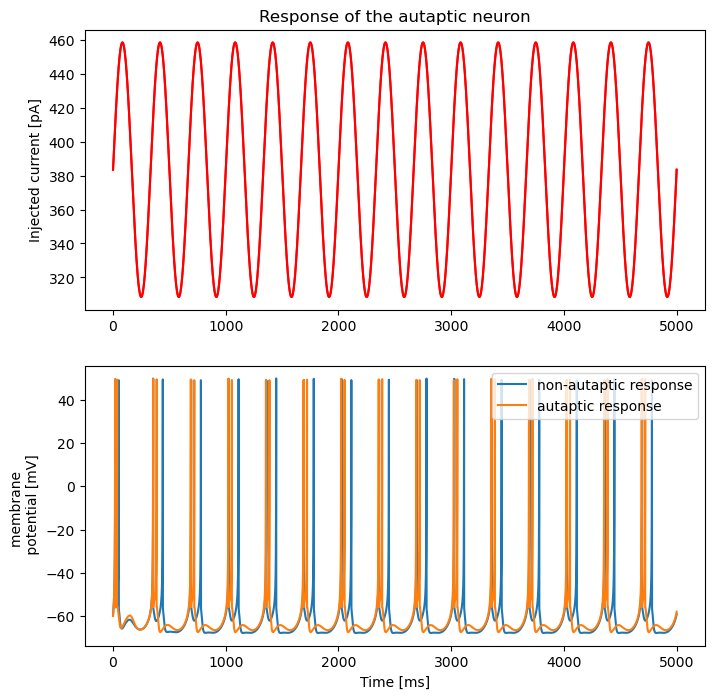

In [3]:
### INPUT is a sinusoid

T = 5000         # ms
dt = 0.01        # ms
N_iter = int(T/dt)

freq = 3 # Hz (Kepecs et al.)
amp = 75
phase = 0

x_ini = np.array([-60, 0, 0])

# pick params here
params = [IB, IB_aut]

batch = batchAQUA(params) 
batch.Initialise(np.array([x_ini, x_ini]), np.zeros(len(params)))

# define the injected current
I_sin, _ = sinusoid(N_iter, dt, freq, amp, phase)
I_sin += threshold + amp

I_inj = np.array([I_sin, I_sin])

# simulate
X_sin, time, spikes_sin = batch.update_batch(dt, N_iter, I_inj)

## plot the outputs

fig, ax = plt.subplots(2, 1, figsize = (8, 8))

#split = np.arange(90000, 120000)
split = []
label = 'non-autaptic response'
fig, ax = plot_potential_versus_injected(X_sin[0], time, I_sin, fig = fig, ax = ax, label = label) # non-autaptic

label = 'autaptic response'
fig, ax = plot_potential_versus_injected(X_sin[1], time, I_sin, fig = fig, ax = ax, label = label) # autaptic
ax[0].set_title("Response of the autaptic neuron")

plt.legend()
plt.show()

In [ ]:
### INPUT is a sinusoid

T = 5000         # ms
dt = 0.01        # ms
N_iter = int(T/dt)

x_ini = np.array([-60, 0, 0])

# pick params here
params = [IB, IB_aut]

batch = batchAQUA(params) 
batch.Initialise(np.array([x_ini, x_ini]), np.zeros(len(params)))

# define the injected current
offset = 50
amplitude = 100
cutoff = 5    # Hz
I_fwn = filtered_white_noise(T/1000, dt, amplitude = amplitude, cutoff = cutoff, poles = 10)
I_fwn += threshold + offset

I_inj = np.array([I_fwn, I_fwn])


# simulate
X_fwn, time, spikes_fwn = batch.update_batch(dt, N_iter, I_inj)



100%|██████████| 499999/499999 [00:58<00:00, 8484.45it/s]


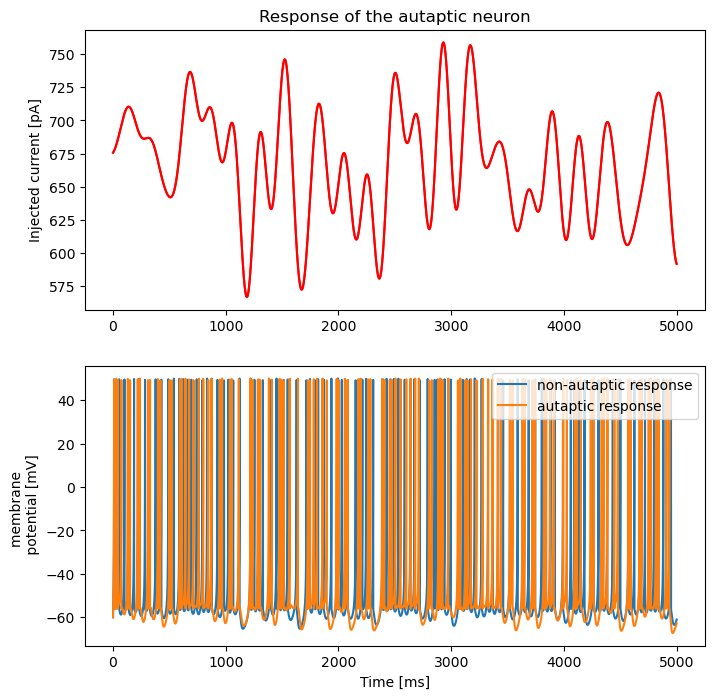

In [12]:
# plot outputs

fig, ax = plt.subplots(2, 1, figsize = (8, 8))

#split = np.arange(200000, 300000)
split = []
label = 'non-autaptic response'
fig, ax = plot_potential_versus_injected(X_fwn[0], time, I_fwn, split = split, fig = fig, ax = ax, label = label) # non-autaptic

label = 'autaptic response'
fig, ax = plot_potential_versus_injected(X_fwn[1], time, I_fwn, split = split, fig = fig, ax = ax, label = label) # autaptic
ax[0].set_title("Response of the autaptic neuron")

plt.legend()
plt.show()

[   9.6          19.55         32.74         53.97        101.12
  136.68        186.58        230.97        283.79        324.57
  377.92        428.37        489.82        540.14        587.98
  622.08        659.          694.65        742.47        792.28
  834.11        875.98        926.45        984.4        1023.02
 1066.11       1121.96       1219.66       1254.05       1291.49
 1329.69       1401.01       1450.6        1479.72       1512.93
 1549.24       1628.45       1715.54       1747.55       1788.08
 1819.58       1868.16       1936.93       1995.47       2029.45
 2081.68       2152.43       2211.71       2245.14       2307.74
 2391.87000001 2426.79000001 2460.99000001 2491.55000001 2531.69000001
 2587.55000001 2637.55000001 2674.76000001 2721.02000001 2791.30000001
 2853.12000002 2878.06000002 2909.67000002 2940.74000002 2996.18000002
 3075.03000002 3103.03000002 3137.18000002 3166.87000002 3209.04000002
 3270.06000002 3326.76000003 3369.45000003 3416.69000003 3460.6600

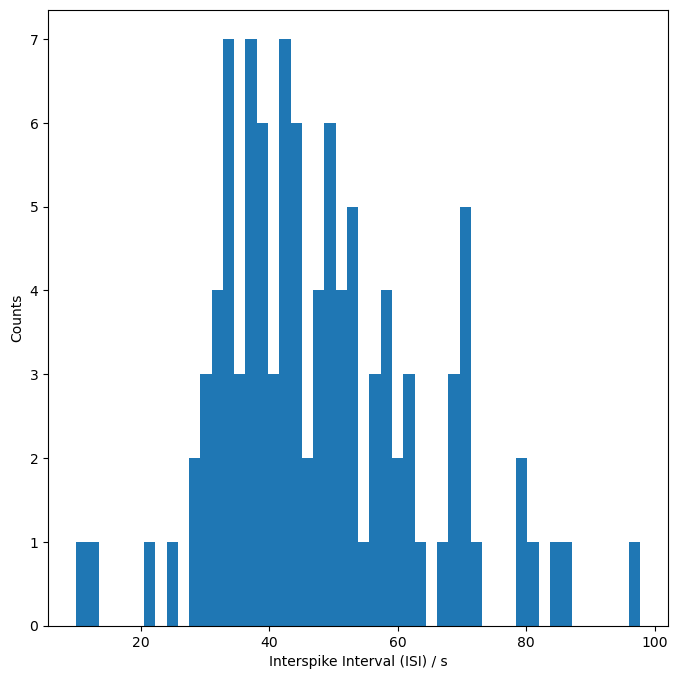

In [14]:
# 
print(spikes_fwn[0])
print(np.ediff1d(spikes_fwn[0]))
print("- - - - - - -")
print(spikes_fwn[1])
print(np.ediff1d(spikes_fwn[1]))
print("- - - - - - -")


fig, ax = plot_ISI_dist(spikes_fwn[0])

#plt.plot(spikes_fwn[0])

plt.show()